In [ ]:
EDAV ASSIGNMENT-2 

AMUKTA MALYA YAJAMANYAM
1601-23-733-003
CSE-1 | 6TH-SEMESTER

In [1]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")  
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


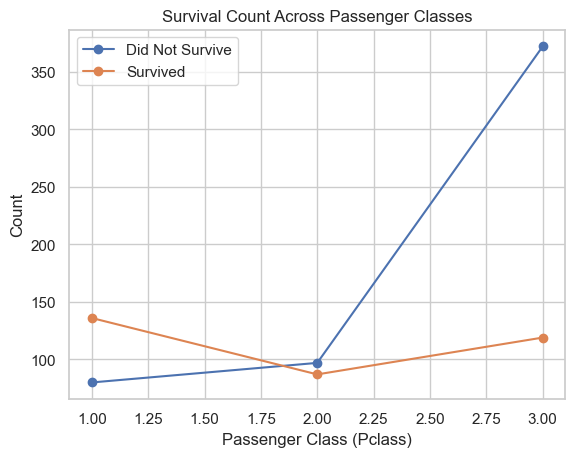

In [4]:
#Q.1 Line Plot (Survival vs Pclass)

survival_counts = df.groupby(['Pclass', 'Survived']).size().unstack()

survival_counts.plot(kind='line', marker='o')
plt.title("Survival Count Across Passenger Classes")
plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

In [ ]:
# Observation:
The line plot shows a clear relationship between passenger class and survival outcomes. 

- 1st Class (Pclass = 1): The number of survivors is higher than non-survivors, indicating better survival chances for higher-class passengers.
- 2nd Class (Pclass = 2): Survival and non-survival counts are relatively close, suggesting moderate survival probability.
- 3rd Class (Pclass = 3): A significantly higher number of passengers did not survive compared to those who survived.

# Insight:
There is a strong trend where survival probability decreases as passenger class lowers. This suggests that passengers in higher classes had better access to safety measures (e.g., lifeboats), highlighting the impact of socioeconomic status on survival during the disaster.

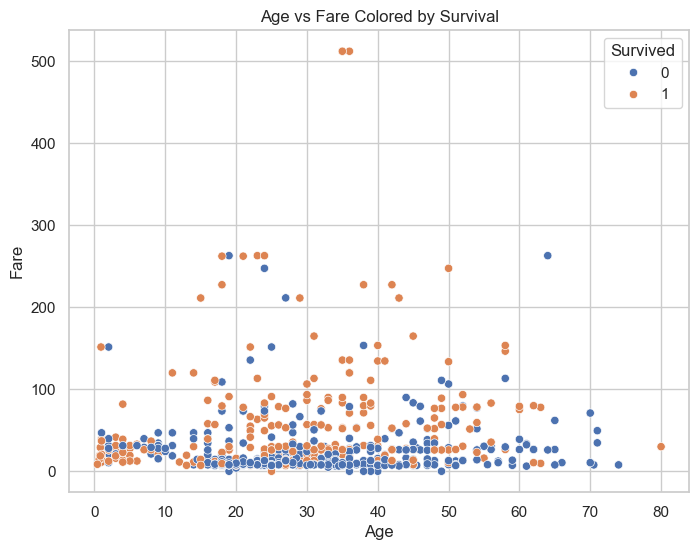

In [5]:
#Q.2 Scatter Plot (Age vs Fare)

plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare Colored by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived")
plt.show()

In [ ]:
Observations:
- Most points concentrated at low fare values (<100)
- Survivors more visible in higher fare regions
- Heavy overlap between survivors and non-survivors across ages
- Few outliers with extremely high fares

Insights:
- Fare shows stronger separation than Age
- Higher fare passengers had better survival chances
- Age has weak influence due to overlap
- Data is skewed toward low-fare passengers

Conclusion:
Fare is a more discriminative feature than Age, with higher fare passengers showing better survival likelihood despite overlap

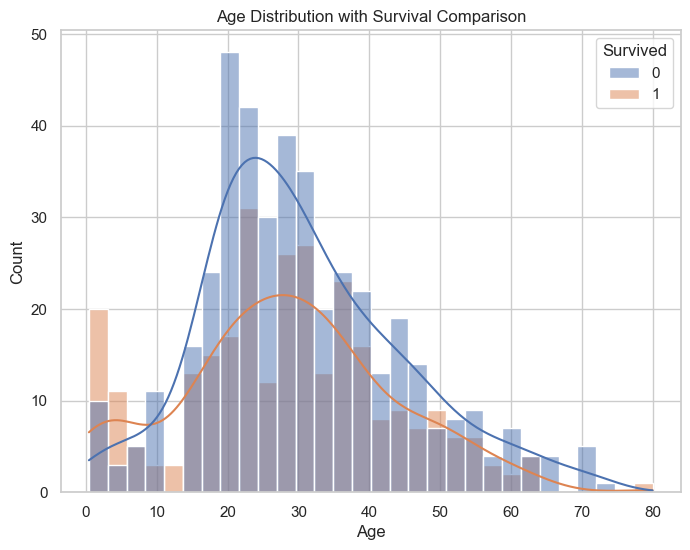

In [6]:
#Q.3 Histogram + Density

plt.figure(figsize=(8,6))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution with Survival Comparison")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
Observations:
- Age distribution peaks around 20–35 years for both groups
- Survivors and non-survivors show heavy overlap across most age ranges
- Slightly higher concentration of survivors in younger age groups
- Distribution is right-skewed with fewer older passengers

Insights:
- Age alone does not clearly separate survival outcomes
- Younger passengers had a marginally higher survival tendency
- Majority of passengers fall in the young adult category
- Older age groups are underrepresented in the dataset

Conclusion:
Age is a weak predictor of survival, with only a slight advantage observed for younger passengers and significant overlap between both groups

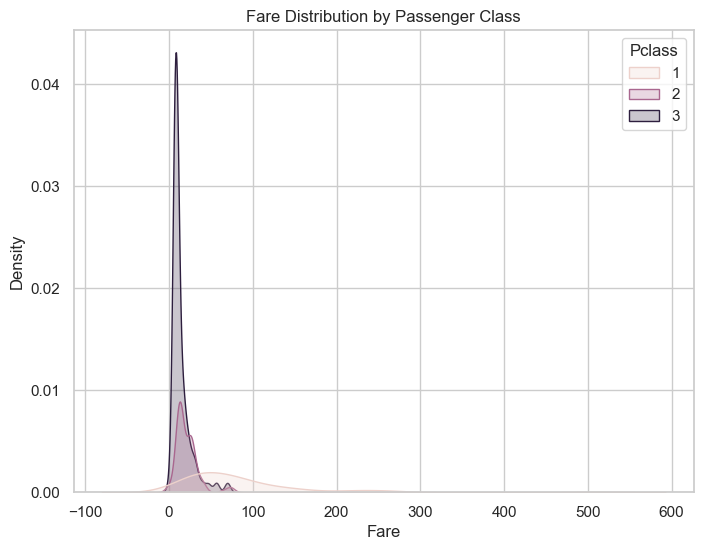

In [7]:
#Q.4 KDE Plot (Fare by Class)

plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x='Fare', hue='Pclass', fill=True)
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

In [ ]:
Observations:
- Pclass 3 shows a sharp peak at very low fare values
- Pclass 2 has a moderate spread with slightly higher fares than class 3
- Pclass 1 spans a wide range with a long tail towards very high fares
- Significant overlap exists in lower fare regions across all classes

Insights:
- Lower classes are concentrated in low fare ranges indicating budget travel
- Higher class passengers exhibit high variability in fare payments
- Pclass 1 has the widest spread, reflecting diverse ticket pricing
- Fare distribution is highly right-skewed, especially for higher classes

Conclusion:
Passenger class strongly influences fare distribution, with Pclass 1 showing the widest variability and higher fare range, while Pclass 3 is tightly concentrated in the lowest fare segment

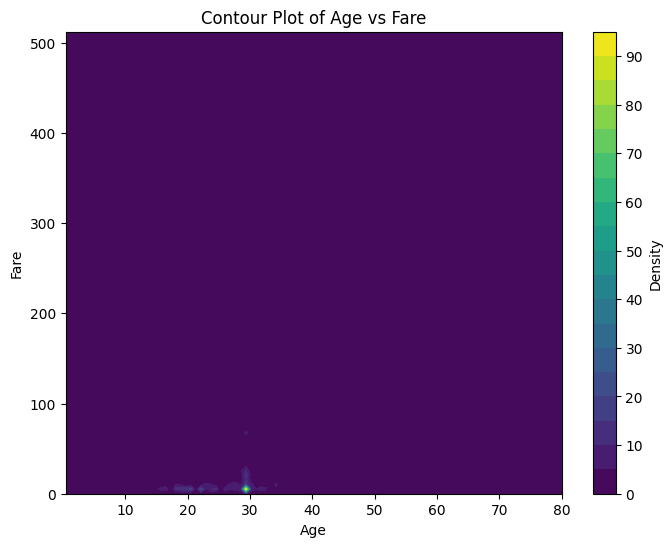

In [12]:
#Q.5 Contour Plot (Age vs Fare)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic-Dataset.csv')

age = df['Age'].fillna(df['Age'].mean())
fare = df['Fare'].fillna(df['Fare'].mean())

# Grid
x = np.linspace(age.min(), age.max(), 100)
y = np.linspace(fare.min(), fare.max(), 100)
X, Y = np.meshgrid(x, y)

# FIX: bins must match grid size
Z, _, _ = np.histogram2d(age, fare, bins=100)
Z = Z.T

# Plot
plt.figure(figsize=(8,6))
plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(label='Density')

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Contour Plot of Age vs Fare")

plt.show()

In [ ]:
Observations:
- High-density region concentrated at lower Fare values (≈ 0–50)
- Age cluster is prominent between ~20–35 years
- Sparse distribution at higher Fare ranges (>100)
- Very few passengers in extreme age or fare combinations

Insights:
- Majority of passengers were young adults paying low fares
- Fare distribution is highly skewed, with most values near the lower range
- High-fare passengers are rare, indicating class imbalance
- Age and Fare jointly show a dense typical passenger zone (mid-age, low fare)

Conclusion:
Typical Titanic passengers were young adults traveling on lower fares, with limited representation in higher fare brackets or extreme age groups

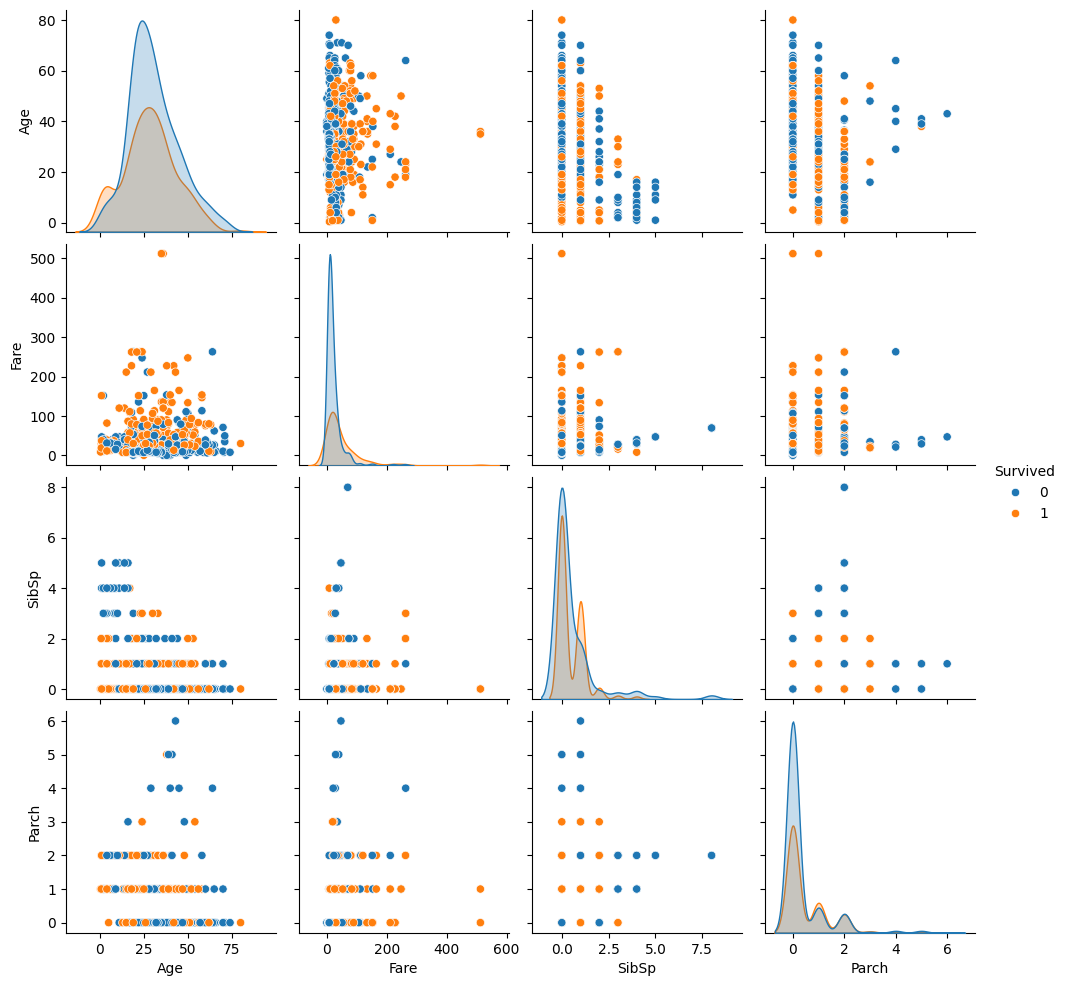

In [10]:
#Q.6 Pairplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['Age','Fare','SibSp','Parch','Survived']], hue='Survived')
plt.show()

In [ ]:
Observations:
- Fare shows clear separation between survivors and non-survivors.
- Survivors are concentrated at higher fares.
- SibSp and Parch have moderate positive relation.
- Age shows heavy overlap across survival groups.

Insights:
- Fare is the most discriminative feature.
- Family-related features have mild influence.
- Age alone is a weak predictor.

Conclusion:
Fare best distinguishes survival, while Age, SibSp, and Parch have limited predictive power.

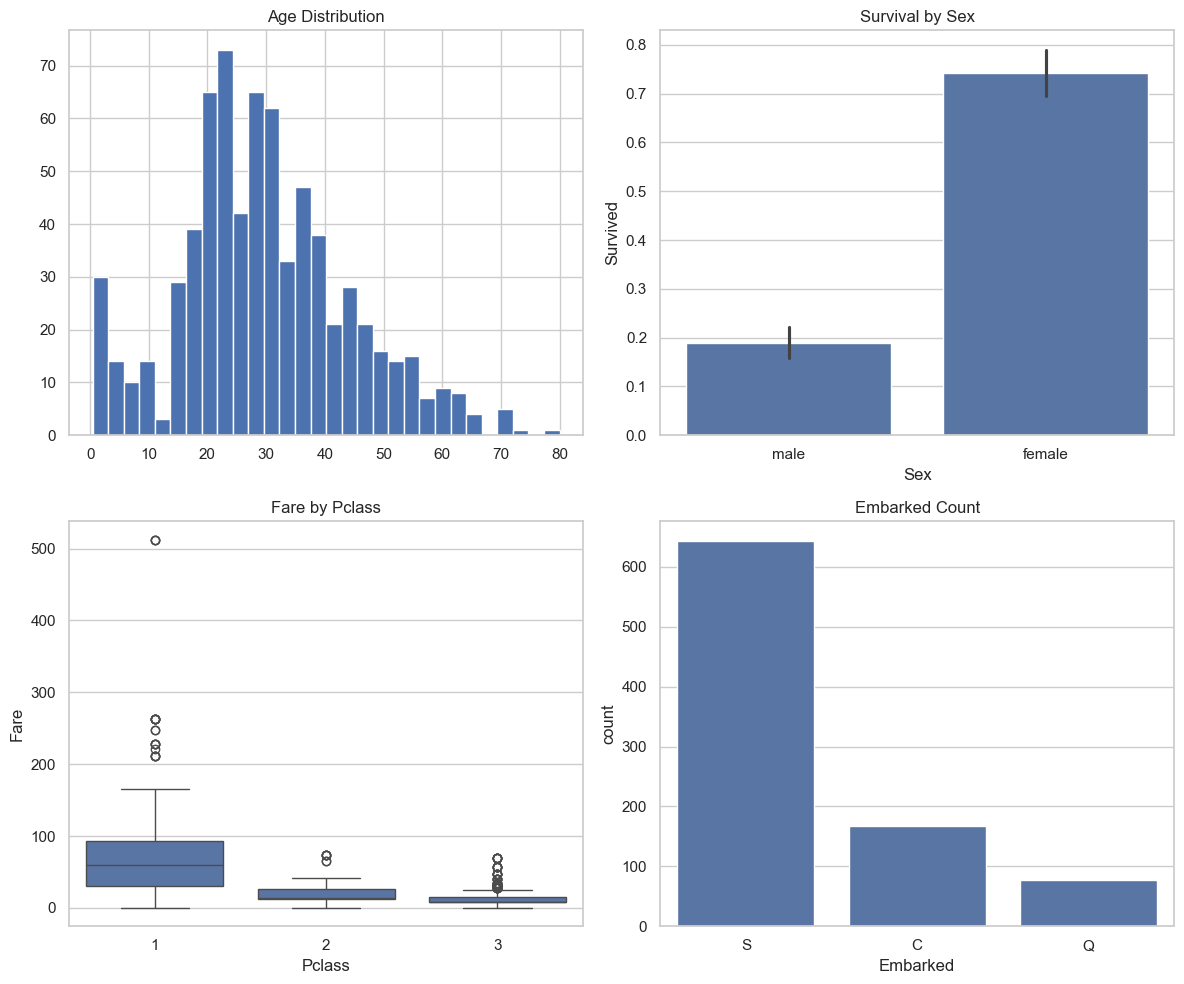

In [10]:
#Q.7 2x2 Subplots

fig, axes = plt.subplots(2,2, figsize=(12,10))

# (a)
axes[0,0].hist(df['Age'].dropna(), bins=30)
axes[0,0].set_title("Age Distribution")

# (b)
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title("Survival by Sex")

# (c)
sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[1,0])
axes[1,0].set_title("Fare by Pclass")

# (d)
sns.countplot(x='Embarked', data=df, ax=axes[1,1])
axes[1,1].set_title("Embarked Count")

plt.tight_layout()
plt.show()

In [ ]:
Observations:
- Most passengers were aged between 20 and 35 years.
- Female passengers had a much higher survival rate than males.
- Pclass 1 had the highest fares with many outliers.
- Most passengers embarked from Southampton (S).

Insights:
- Young adults formed the majority of travelers.
- Gender strongly influenced survival chances.
- Higher passenger class was associated with expensive tickets.
- Southampton was the main boarding port.

Conclusion:
Age, sex, passenger class, and embarkation point reveal important patterns in Titanic passenger demographics and survival.

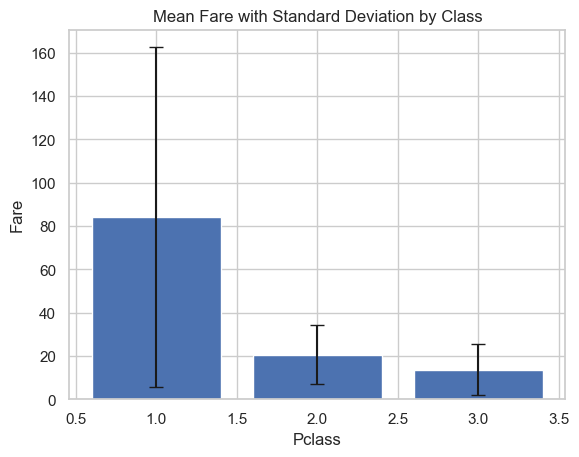

In [11]:
#Q.8 Error Bars(Mean Fare)

stats = df.groupby('Pclass')['Fare'].agg(['mean','std'])

plt.bar(stats.index, stats['mean'], yerr=stats['std'], capsize=5)
plt.title("Mean Fare with Standard Deviation by Class")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

In [ ]:
Observations:
- Pclass 1 has the highest mean fare.
- Mean fare decreases from Pclass 1 to Pclass 3.
- Pclass 1 shows the largest standard deviation.
- Pclass 2 and Pclass 3 have lower fare variability.

Insights:
- Higher passenger classes paid significantly more.
- First-class fares varied widely due to premium ticket ranges.
- Lower classes had more uniform pricing.

Conclusion:
Passenger class strongly affects fare, with first class having the highest and most variable ticket prices.

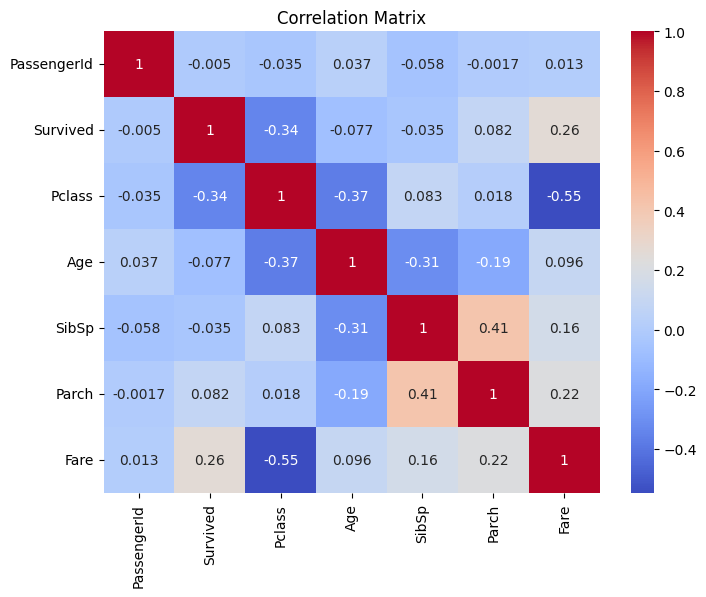

In [11]:
#Q.9 Heatmap

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
Observations:
- Fare and Pclass are strongly negatively correlated.
- Survived is positively related to Fare and negatively to Pclass.
- SibSp and Parch show moderate positive correlation.
- Age has weak correlation with most features.

Insights:
- Passenger class and fare strongly influence survival.
- Most other variables have limited impact.

Conclusion:
Pclass and Fare are the key factors affecting survival.

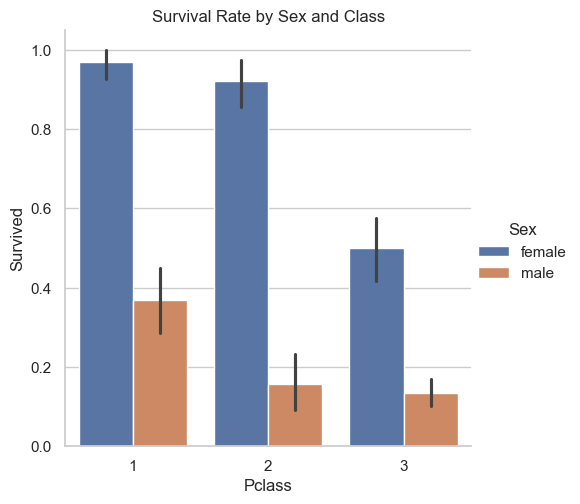

In [13]:
#Q.10 Survival Rate by Sex and Passenger Class

sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=df)
plt.title("Survival Rate by Sex and Class")
plt.show()

In [ ]:
Observations:
- Females have much higher survival rates than males in all classes.
- Survival is highest in 1st class and lowest in 3rd class.
- Male survival is consistently low, especially in 2nd and 3rd class.

Insights:
- Gender is the strongest factor influencing survival.
- Higher passenger class increases chances of survival.
- Females in higher classes had the best survival outcomes, while males in lower classes had the worst.

Conclusion:
Both sex and passenger class affect survival, with gender having a stronger impact.